# Пошуковий аналіз датасету (EDA)

## 1. Загальний опис датасету та бізнес-контексту
- **Бізнес-тема:** Управління відтоком абонентів телекомунікаційної компанії.
- **Мета аналізу:** Дослідити структуру даних, виявити проблеми якості, оцінити розподіл ознак та знайти залежності, що впливають на відтік клієнтів.
- **Джерело даних:** Внутрішні системи компанії (CRM, Білінг).
- **Задача машинного навчання:** Бінарна класифікація.
- **Цільова змінна (Target):** `is_churn` (1 — клієнт розірвав контракт, 0 — клієнт залишився).
- **Основні атрибути:** 39 стовпців та 7043 рядки. Датасет містить ідентифікатори (`customer_id`), демографічні дані (напр., `age`, `gender`), фінансові показники (напр., `monthly_charge`, `total_charges`), інформацію про послуги (`internet_type`, `phone_service`) та метрики лояльності (`tenure_in_months`).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Налаштування відображення таблиць в Pandas
pd.set_option('display.max_columns', None)

# Завантаження датасету
file_path = Path("../data/processed/telecom_customer_churn.parquet")
df = pd.read_parquet(file_path)

# Вивід розмірності датасету
print(f"Кількість рядків: {df.shape[0]}")
print(f"Кількість стовпців: {df.shape[1]}")

Кількість рядків: 7043
Кількість стовпців: 39


## 2. Первинний огляд датасету

In [15]:
# 1. Перегляд перших 5 записів
print("--- Перші 5 записів датасету ---")
display(df.head())

--- Перші 5 записів датасету ---


,customer_id,gender,age,married,number_of_dependents,city,zip_code,latitude,longitude,number_of_referrals,tenure_in_months,offer,phone_service,avg_monthly_long_distance_charges,multiple_lines,internet_service,internet_type,avg_monthly_gb_download,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason,is_churn
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,No Churn,No Churn,0
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,No Churn,No Churn,0
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,1
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,1


In [19]:
# 2. Зведена інформація про датафрейм (типи даних, кількість Non-Null)
print("\n--- Інформація про структуру (info) ---")
df.info()


--- Інформація про структуру (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   str    
 1   gender                             7043 non-null   str    
 2   age                                7043 non-null   int64  
 3   married                            7043 non-null   str    
 4   number_of_dependents               7043 non-null   int64  
 5   city                               7043 non-null   str    
 6   zip_code                           7043 non-null   int64  
 7   latitude                           7043 non-null   float64
 8   longitude                          7043 non-null   float64
 9   number_of_referrals                7043 non-null   int64  
 10  tenure_in_months                   7043 non-null   int64  
 11  offer                     

In [17]:
# 3. Базова статистика для числових ознак
print("\n--- Статистика числових ознак (describe) ---")
display(df.describe())


--- Статистика числових ознак (describe) ---


,age,number_of_dependents,zip_code,latitude,longitude,number_of_referrals,tenure_in_months,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,is_churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,0.265370
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,0.441561
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,0.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,0.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,0.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,1.000000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,1.000000


In [18]:
# 4. Базова статистика для категоріальних/текстових ознак
print("\n--- Статистика категоріальних ознак ---")
display(df.describe(include=['object', 'string']))


--- Статистика категоріальних ознак ---


,customer_id,gender,married,city,offer,phone_service,multiple_lines,internet_service,internet_type,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,customer_status,churn_category,churn_reason
count,7043,7043,7043,7043,3166,7043,6361,7043,5517,5517,5517,5517,5517,5517,5517,5517,5517,7043,7043,7043,7043,7043,7043
unique,7043,2,2,1106,5,2,2,2,3,2,2,2,2,2,2,2,2,3,2,3,3,6,21
top,0002-ORFBO,Male,No,Los Angeles,Offer B,Yes,No,Yes,Fiber Optic,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,No Churn,No Churn
freq,1,3555,3641,293,824,6361,3390,5517,3035,3498,3088,3095,3473,2810,2785,3029,4745,3610,4171,3909,4720,5174,5174


## 3. Аналіз повноти та якості даних
На цьому етапі ми досліджуємо датасет на наявність пропущених значень (NaN), повних дублікатів рядків та оцінюємо загальну якість даних перед подальшим моделюванням.

In [21]:
# 1. Перевірка на наявність повних дублікатів
duplicates_count = df.duplicated().sum()
print(f"Кількість повних дублікатів рядків: {duplicates_count}\n")

# 2. Аналіз пропущених значень (NaN)
# Рахуємо абсолютну кількість та відсоток пропусків для кожної колонки
missing_data = pd.DataFrame({
    'Missing_Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

# Фільтруємо лише ті колонки, де є хоча б один пропуск, і сортуємо за спаданням
missing_data = missing_data[missing_data['Missing_Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("--- Таблиця пропущених значень ---")
display(missing_data.round(2))

# 3. Перевірка унікальності ідентифікаторів
unique_ids = df['customer_id'].nunique()
print(f"\nЗагальна кількість рядків: {len(df)}")
print(f"Кількість унікальних customer_id: {unique_ids}")
if len(df) == unique_ids:
    print("-> Кожен рядок відповідає унікальному клієнту (немає прихованих дублікатів ID).")
else:
    print("-> Є дублювання ідентифікаторів клієнтів!")

Кількість повних дублікатів рядків: 0

--- Таблиця пропущених значень ---


,Missing_Values,Percentage (%)
offer,3877,55.05
avg_monthly_gb_download,1526,21.67
internet_type,1526,21.67
online_backup,1526,21.67
online_security,1526,21.67
streaming_tv,1526,21.67
streaming_movies,1526,21.67
device_protection_plan,1526,21.67
premium_tech_support,1526,21.67
streaming_music,1526,21.67



Загальна кількість рядків: 7043
Кількість унікальних customer_id: 7043
-> Кожен рядок відповідає унікальному клієнту (немає прихованих дублікатів ID).


### Висновки щодо якості даних:
1. **Дублікати:** Повних дублікатів рядків або дублювання `customer_id` не виявлено.
2. **Аналіз пропусків:** - Найбільш проблемною колонкою є `offer` (~55% пропусків). 
   - Група колонок послуг Інтернету (`internet_type`, `online_security` тощо) має однакову кількість пропусків — 1526 (~21.6%). 
   - Група колонок телефонного зв'язку (`multiple_lines`, `avg_monthly_long_distance_charges`) має 682 пропуски (~9.6%).
3. **Придатність без очищення:** Датасет **не можна** використовувати для навчання моделей у поточному вигляді. Більшість ML-алгоритмів (крім певних реалізацій дерев) не підтримують `NaN` значення. 

**Топ-3 потенційні ризики для моделювання:**
1. **Ризик втрати даних:** Якщо просто видалити колонку `offer` (через 55% пропусків), ми втратимо важливий маркетинговий сигнал. Пропуски тут є структурними і означають "немає активної пропозиції".
2. **Ризик помилкової імп'ютації:** Заповнення пропусків у колонках типу `internet_type` середнім значенням або модою буде грубою бізнес-помилкою. Ці пропуски означають, що клієнт взагалі не підключив інтернет. Їх треба замінити на окрему категорію, наприклад, "No Internet Service".
3. **Ризик витоку даних (Data Leakage):** Наявність в ознаках колонок `churn_category` та `churn_reason` є небезпечною, оскільки вони заповнюються *лише після* того, як клієнт пішов. Використання їх як ознак для прогнозування майбутнього відтоку призведе до перенавчання моделі (модель "підглядатиме" у відповідь). Їх треба буде видалити перед тренуванням.

## 4. Аналіз цільової змінної (Target)
Цільова змінна в нашій бізнес-задачі — `is_churn`.
* `1` означає, що клієнт розірвав контракт (відтік).
* `0` означає, що клієнт продовжує користуватися послугами (лояльний).

Для задач класифікації критично важливо оцінити розподіл класів, щоб виявити дисбаланс та зрозуміти, які наслідки це матиме для вибору метрик і алгоритмів.

--- Розподіл цільової змінної (is_churn) ---
Клас 0: 5174 записів (73.46%)
Клас 1: 1869 записів (26.54%)


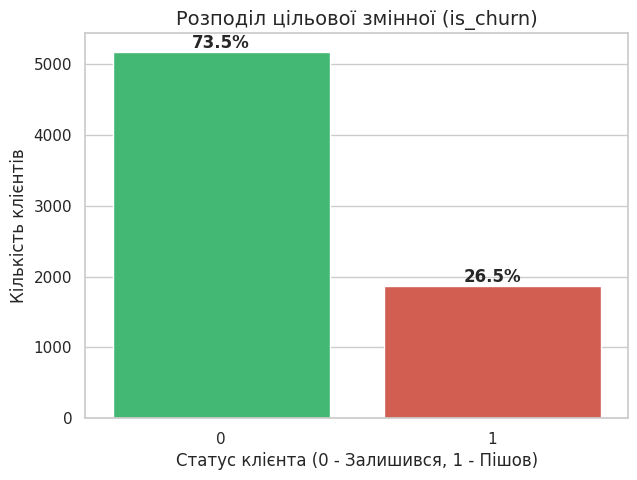

In [23]:
# Рахуємо кількість записів для кожного класу
target_counts = df['is_churn'].value_counts()
target_percentage = df['is_churn'].value_counts(normalize=True) * 100

print("--- Розподіл цільової змінної (is_churn) ---")
for idx, val in target_percentage.items():
    print(f"Клас {idx}: {target_counts[idx]} записів ({val:.2f}%)")

# Візуалізація розподілу
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='is_churn', palette=['#2ecc71', '#e74c3c'], hue='is_churn', legend=False)
plt.title('Розподіл цільової змінної (is_churn)', fontsize=14)
plt.xlabel('Статус клієнта (0 - Залишився, 1 - Пішов)', fontsize=12)
plt.ylabel('Кількість клієнтів', fontsize=12)

# Додаємо відсотки на графік
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), ha='center', fontsize=12, fontweight='bold')

plt.show()

**Наслідки для моделювання:**
Спостерігається дисбаланс класів: ~26.5% клієнтів пішли, а ~73.5% залишилися. Це означає, що використання метрики `Accuracy` буде оманливим (модель, яка просто скаже "ніхто не піде", вже матиме точність 73.5%). Нам доведеться використовувати метрики `F1-score`, `Precision`, `Recall` та `ROC-AUC`, а алгоритмам призначати ваги для класів (наприклад, `class_weight='balanced'`).

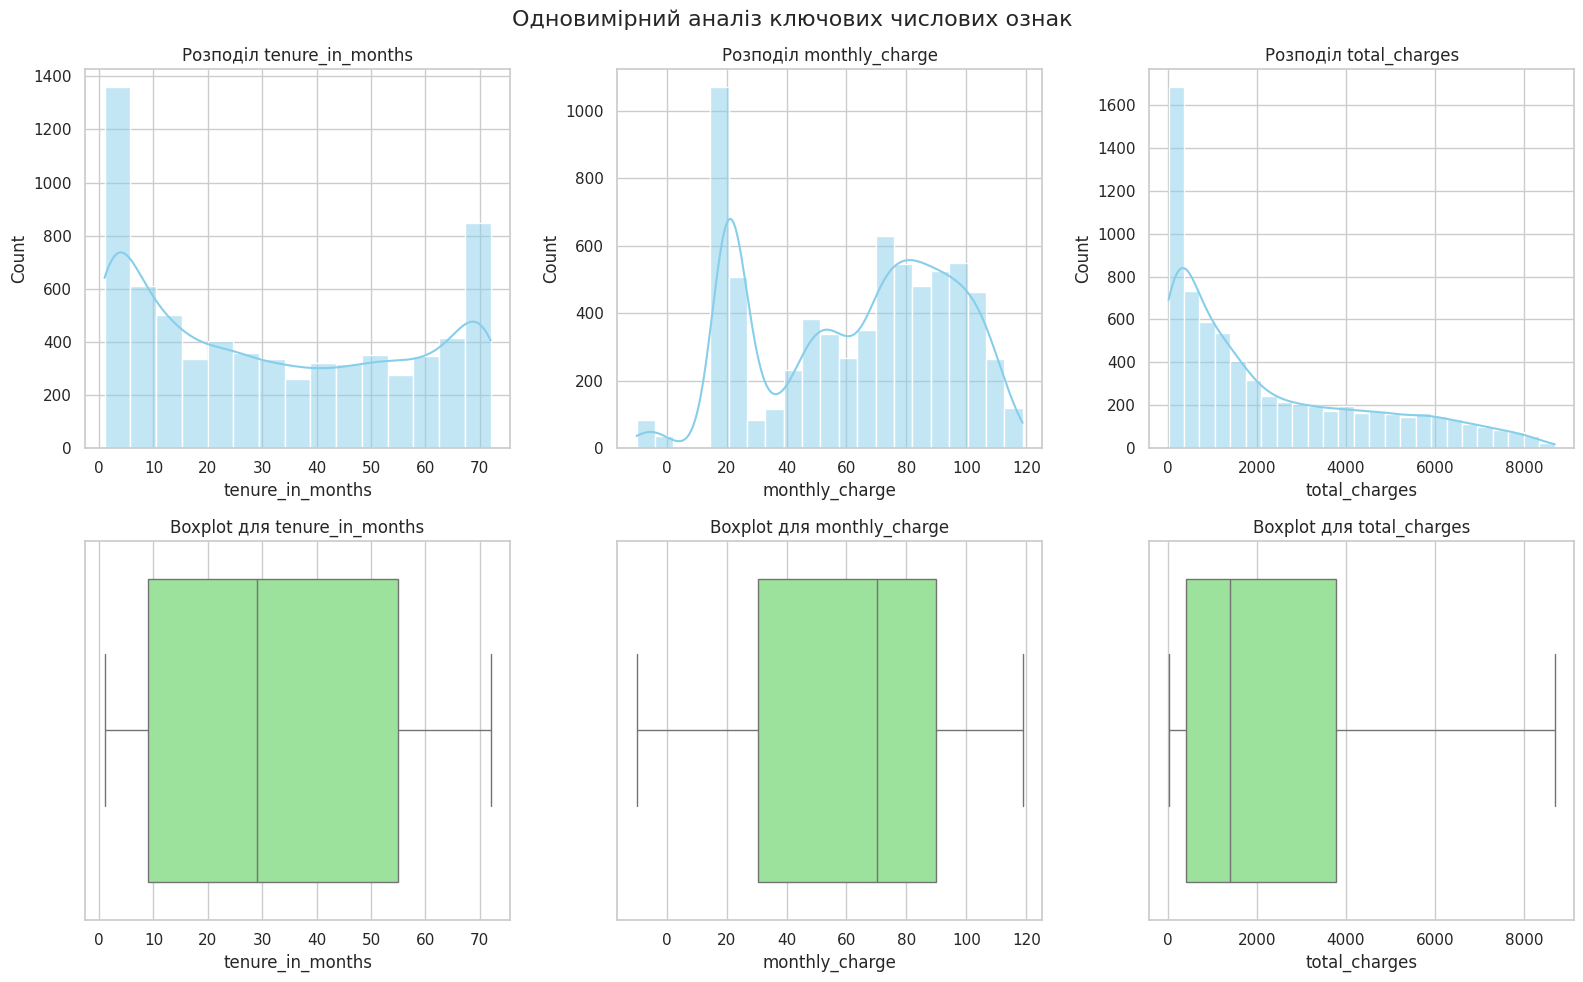

In [24]:
# Одновимірний аналіз ключових числових ознак
# Розподіл значень; можливі викиди

numeric_features = ['tenure_in_months', 'monthly_charge', 'total_charges']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Одновимірний аналіз ключових числових ознак', fontsize=16)

for i, col in enumerate(numeric_features):
    # Гістограми (Генеруємо розподіл)
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Розподіл {col}')
    
    # Boxplots (Пошук викидів)
    sns.boxplot(x=df[col], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'Boxplot для {col}')

plt.tight_layout()
plt.show()

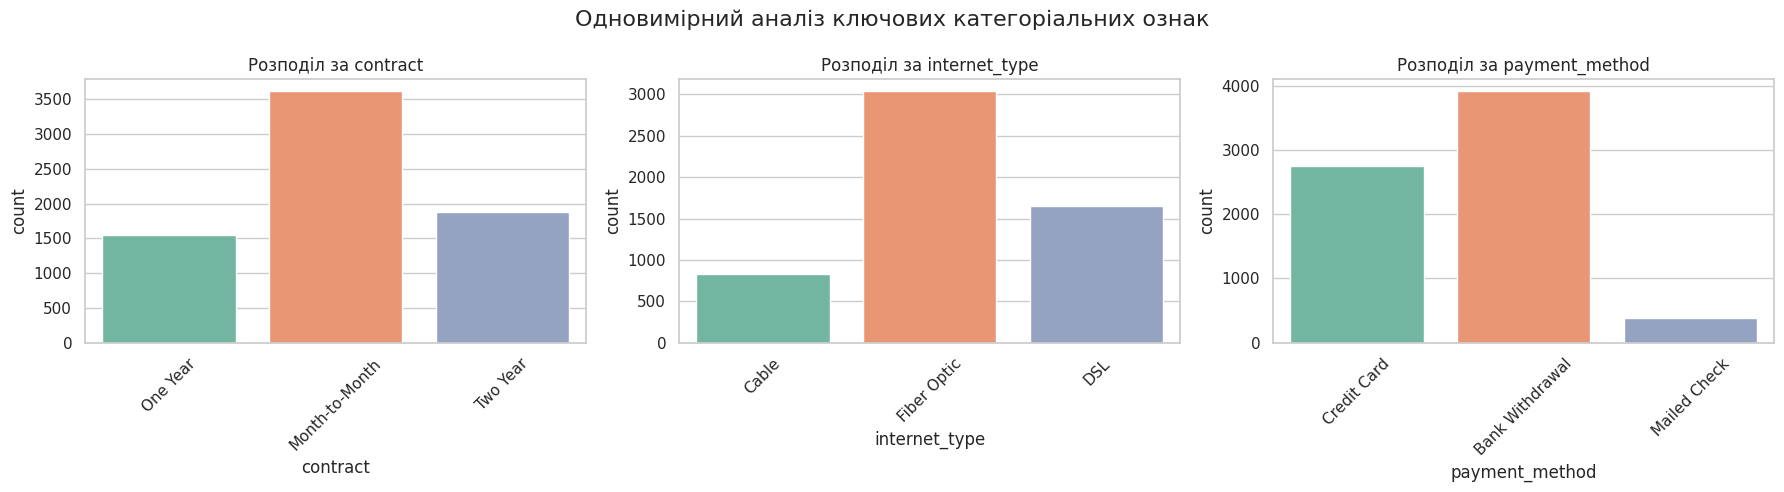

In [26]:
# Одновимірний аналіз категоріальних ознак
# Частоти категорій; дисбаланс категорій

categorical_features = ['contract', 'internet_type', 'payment_method']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Одновимірний аналіз ключових категоріальних ознак', fontsize=16)

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'Розподіл за {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Висновки з одновимірного аналізу ознак:

**1. Числові ознаки (Гістограми та Boxplots):**
* **`tenure_in_months` (Тривалість обслуговування):** Розподіл є яскраво вираженим бімодальним (двогорбим). Ми бачимо величезний сплеск на рівні 1-5 місяців (дуже багато нових клієнтів) і ще один великий сплеск на рівні 70+ місяців (дуже лояльні "ветерани"). 
* **`monthly_charge` (Щомісячний платіж):** Має кілька піків. Яскравий пік біля $20 вказує на великий сегмент клієнтів із базовими дешевими послугами (ймовірно, лише телефон). Інша велика група розмазана в діапазоні $70-$100 — це преміум-клієнти з інтернетом та додатковими послугами.
* **Викиди (Outliers):** Графіки Boxplot показують, що в наших ключових числових ознаках немає екстремальних аномалій (точок за "вусами" графіка). Дані чисті.

**2. Категоріальні ознаки (Bar charts):**
* **`contract`:** Абсолютна більшість клієнтів перебувають на контракті **Month-to-Month** (помісячна оплата). Це дуже тривожний сигнал для бізнесу, адже такі клієнти нічим не зобов'язані компанії і можуть піти в будь-який момент. Вони — наша головна зона ризику.
* **`internet_type`:** Найпопулярнішим підключенням є **Fiber Optic** (Оптоволокно).
* **`payment_method`:** Більшість користується автоматичним зняттям коштів з банку (**Bank Withdrawal**), тоді як паперові чеки відходять у минуле.

## 5. Двовимірний та багатовимірний аналіз
На цьому етапі ми досліджуємо взаємозв'язки між ознаками. 
Основні завдання:
1. Побудувати матрицю кореляцій для числових змінних, щоб виявити мультиколінеарність (ознаки, які дублюють одна одну).
2. Проаналізувати, як ключові категоріальні та числові ознаки впливають на ймовірність відтоку (`is_churn`).

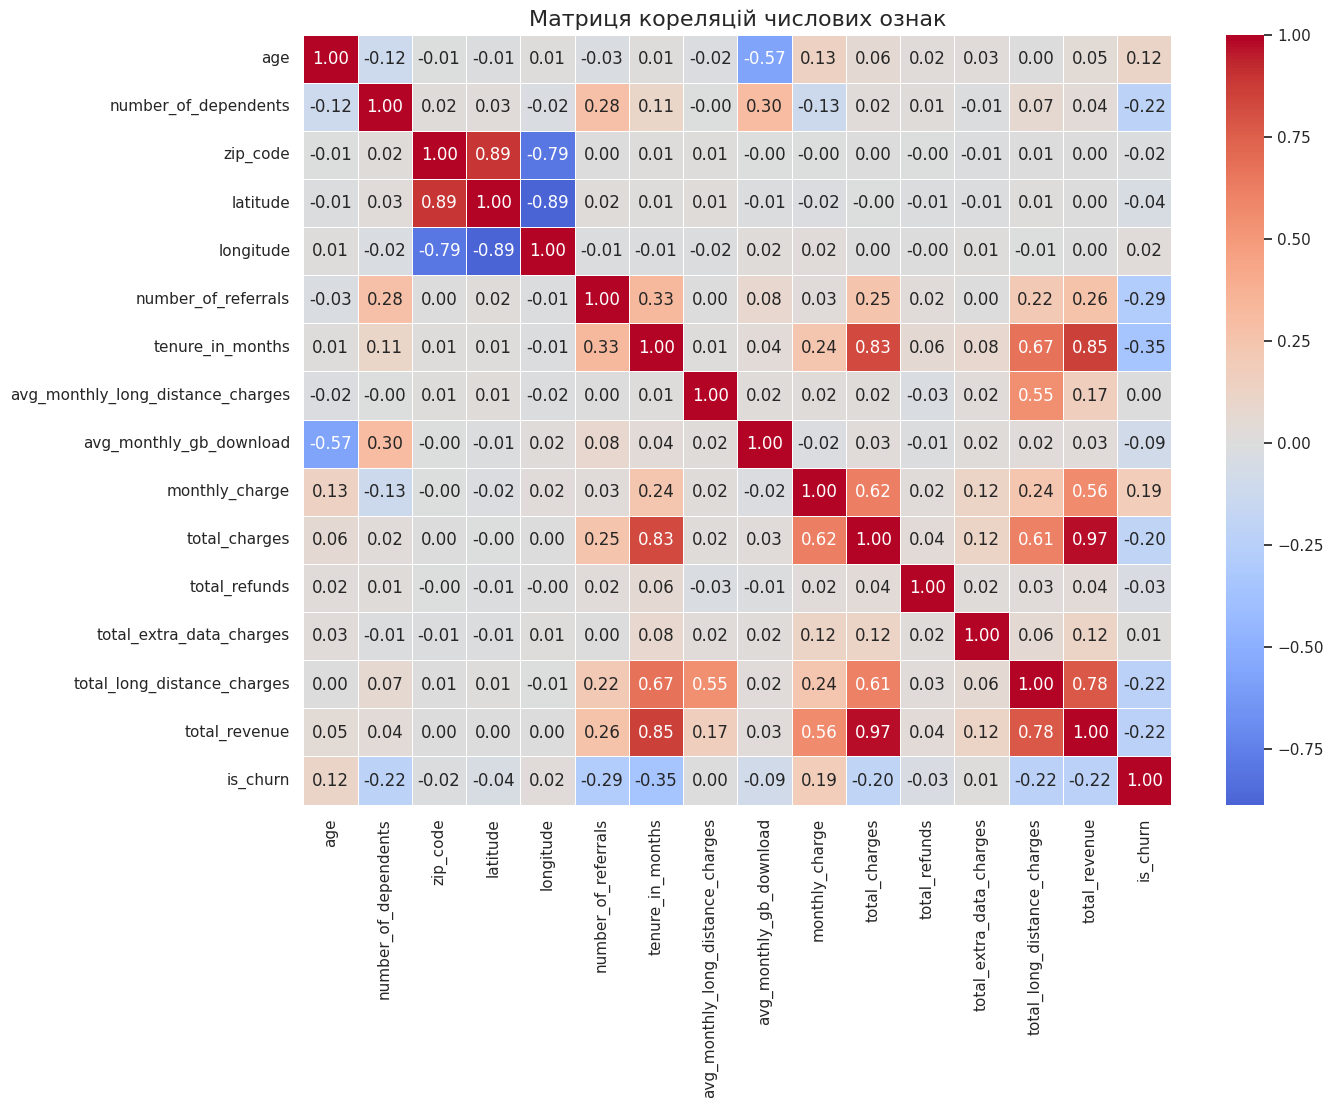

In [27]:
# 1. Матриця кореляцій Пірсона для числових ознак
# Відбираємо лише числові колонки
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Обчислюємо кореляцію
corr_matrix = numeric_df.corr()

# Будуємо Heatmap (Теплову карту)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матриця кореляцій числових ознак', fontsize=16)
plt.show()

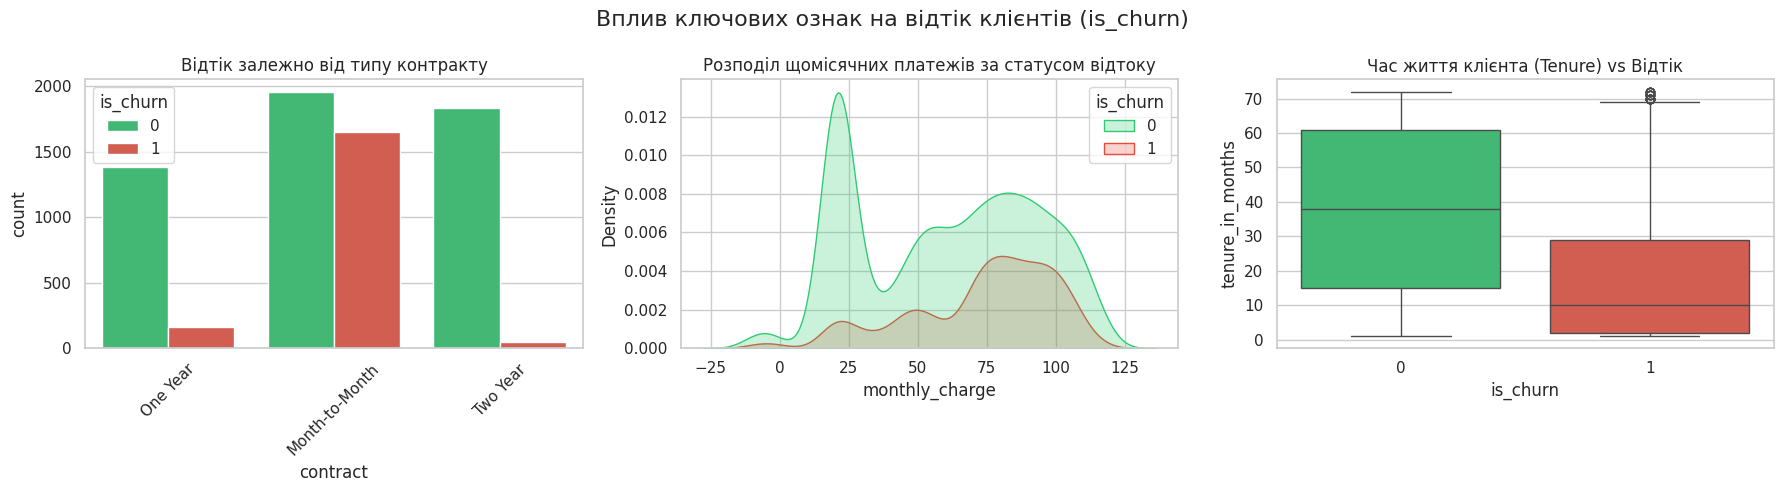

In [29]:
# 2. Взаємозв'язок ключових ознак із цільовою змінною

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Вплив ключових ознак на відтік клієнтів (is_churn)', fontsize=16)

# Графік 1: Відтік за типом контракту (Категоріальна vs Target)
sns.countplot(data=df, x='contract', hue='is_churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Відтік залежно від типу контракту')
axes[0].tick_params(axis='x', rotation=45)

# Графік 2: Відтік залежно від щомісячного платежу (Числова vs Target)
sns.kdeplot(data=df, x='monthly_charge', hue='is_churn', fill=True, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Розподіл щомісячних платежів за статусом відтоку')

# Графік 3: Відтік залежно від часу з компанією (Числова vs Target)
sns.boxplot(data=df, x='is_churn', y='tenure_in_months', palette=['#2ecc71', '#e74c3c'], ax=axes[2], hue='is_churn', legend=False)
axes[2].set_title('Час життя клієнта (Tenure) vs Відтік')

plt.tight_layout()
plt.show()

### Висновки з двовимірного аналізу:

**1. Кореляції між ознаками (Мультиколінеарність):**
* Сильна позитивна кореляція (близько **0.83**) спостерігається між `tenure_in_months` та `total_charges`. Це логічно: чим довше клієнт з нами, тим більшу суму він сумарно сплатив. Для деяких лінійних моделей одну з цих ознак (ймовірно, `total_charges`) доведеться видалити, щоб уникнути перенавчання.
* Змінна `is_churn` має помітну зворотну (від'ємну) кореляцію з `tenure_in_months` (близько **-0.35**). Тобто, чим довше клієнт з нами, тим менша ймовірність, що він піде.

**2. Взаємозв'язок із цільовою змінною (Відтоком):**
* **За контрактом:** Клієнти з контрактом *Month-to-Month* мають катастрофічно високий відсоток відтоку. Натомість клієнти з контрактами на 1 або 2 роки майже не йдуть від компанії (зелений стовпчик абсолютно домінує над червоним). Це головний інсайт для бізнесу: треба переводити людей на довгострокові контракти.
* **За щомісячним платежем (monthly_charge):** Розподіл (KDE plot) показує, що клієнти з високими чеками (в діапазоні $70-$110) йдуть значно частіше, ніж клієнти з дешевими тарифами (~$20). Це може свідчити про те, що преміум-клієнти незадоволені співвідношенням ціна/якість або конкуренти пропонують їм кращі умови.
* **За часом з компанією (tenure):** Boxplot чітко демонструє, що медіанний час життя клієнтів, які пішли (клас 1), становить лише близько 10 місяців. Новачки йдуть найчастіше. Ті, хто пережив рубіж у 2-3 роки, зазвичай залишаються.

## 6. Фінальні аналітичні висновки

На основі проведеного пошукового аналізу даних (EDA) ми можемо дати відповіді на ключові питання щодо подальшої роботи з датасетом:

**1. Чи придатний датасет для вирішення бізнес-задачі?**
Так, датасет є придатним для вирішення задачі прогнозування відтоку. Він містить достатню кількість записів (7043) та охоплює різнобічні аспекти поведінки клієнта (демографію, фінанси, підключені послуги). Однак у поточному (сирому) вигляді його використовувати не можна через наявність структурних пропусків та небезпечних ознак.

**2. Які основні проблеми якості даних виявлено?**
* **Структурні пропуски (NaN):** Виявлено велику кількість пропусків у колонках `offer` (55%), `internet_type` (21.6%) та пов'язаних з інтернетом послугах. Ці пропуски не є помилками, а означають відсутність послуги, тому їх не можна видаляти або заповнювати середнім значенням.
* **Витік даних (Data Leakage):** Наявність колонок `churn_category` та `churn_reason`. Вони заповнюються лише після того, як клієнт розірвав контракт, тому їх використання під час навчання моделі суворо заборонено (модель перенавчиться).
* **Мультиколінеарність:** Висока кореляція (0.83) між `tenure_in_months` та `total_charges`.

**3. Які ознаки потенційно найбільш корисні для моделі?**
Найбільш інформативними виявилися такі ознаки:
* `contract` (Клієнти з контрактом Month-to-Month мають найвищий ризик відтоку).
* `tenure_in_months` (Нові клієнти до 10 місяців йдуть найчастіше).
* `monthly_charge` (Клієнти з високим чеком від $70 до $110 знаходяться в зоні підвищеного ризику).
* `internet_type` (Наявність оптоволокна сильно впливає на патерни поведінки).

**4. Які кроки треба виконати на наступному етапі очищення?**
Для підготовки даних до машинного навчання (Пайплайн очищення) необхідно:
1. **Видалення:** Видалити колонки `customer_id`, `churn_category` та `churn_reason`. 
2. **Імп'ютація пропусків:** Замінити NaN у колонці `offer` на категорію "No Offer", а в колонках інтернет-послуг — на "No Internet Service". Аналогічно для телефонних послуг.
3. **Кодування (Encoding):** Перетворити всі текстові категоріальні змінні (`contract`, `payment_method` тощо) на числові за допомогою One-Hot Encoding або Label Encoding.
4. **Масштабування (Scaling):** Нормалізувати числові ознаки (`monthly_charge`, `tenure_in_months`) за допомогою StandardScaler або MinMaxScaler, особливо якщо будуть використовуватися лінійні моделі чи нейромережі.